# Exercise 1: Linear regression
Initially we will work on 2D points and then expand it out to 3D.

We'll do the necessary imports for the notebook and then generate some data.

The data generation is as follows:
$$
x \sim \mathcal{N}(\mu_x, \sigma_x^2)
$$ 
with $\mu_x=1.5$ being the mean and $\sigma_x = 2.5$ being the standard deviation.

We also add a normally distributed error term with zero mean $\mu_\epsilon=0$ and standard deviation
$\sigma_\epsilon=0.5$.

In [17]:
import numpy as np
import open3d as o3d
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 6/"
# Generate 'random' data
np.random.seed(0)
x = np.random.normal(1.5, 2.5, 100)   # Array of 100 values with mean = 1.5, stddev = 2.5
res = np.random.normal(0, 0.5, 100)       # Generate 100 residual terms (mean=0, std=0.5)
y = 2 + 0.3 * x + res                  # Actual values of Y. The underlying relationship is y = 0.3x + 2 + noise.

We can use the linear regression algorithm from the `sklearn` package.
Here, we setup the model to fit `x` to `y`.

In [18]:
# Reshape x to be a 2D array (matrix) because sklearn expects the input X to be of shape (n_samples, n_features).
# -1 tells numpy to figure out the number of rows automatically, 1 specifies 1 column.
x_r = x.reshape(-1,1) 

# Initialise and fit model
# This calculates the optimal weights (coefficient 0.3 and intercept 2) that minimize the sum of squared errors.
lm = LinearRegression()
model = lm.fit(x_r, y)

We can now predict new outcomes given new data.

In [ ]:
# Draw a new datapoint
tst_x = 2.5 * np.random.randn(1).reshape(-1,1) + 1.5   
print(tst_x)

# Use the trained model to predict the y value for the new x
resulting_y = model.predict(tst_x)
print(resulting_y)

[[0.57704541]]
[2.18951787]


Drawing 200 new samples and plotting them as a line shows us that we have gotten a decent fit.

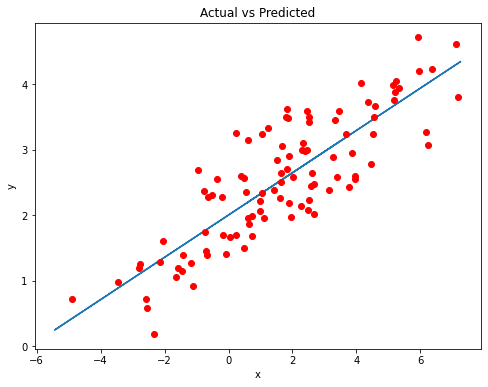

In [19]:
# Generate 200 new x points to visualize the regression line
new_x = 2.5 * np.random.randn(200).reshape(-1,1) + 1.5   
predicted = model.predict(new_x)

plt.figure(figsize=(8, 6))
plt.plot(new_x, predicted)     # regression line (predicted values)
plt.plot(x, y, 'ro')   # scatter plot showing actual data (red dots)
plt.title('Actual vs Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Exercises
### A
Using [Ordinary Least Squares (OLS)](https://en.wikipedia.org/wiki/Ordinary_least_squares), attempt to get a regression line that is equal to the one `sklearn` provides.

Assuming that the data is modeled by the following, having $N$ data points available:
$$
\underbrace{\hat{\mathbf{y}}}_{N \times 1} = \underbrace{\mathbf{X}}_{N\times (K+1)} \underbrace{\beta^\text{*}}_{(K+1) \times 1} + \underbrace{\varepsilon}_{N \times 1} 
$$
Ordinary Least squares optimizes the parameters $\beta$ such that the resdiual error (measured by the Sum of Squared Errors (SSE) objective/loss function $L$) is minimal (regression). That is:
$$
L(\mathbf{X}_i, y_i;\mathbf{\beta}) = \sum_{i=1}^N (y_i - \hat{y_i})^2 \\
\beta^\text{*} = \argmin_\beta L(\mathbf{X}, \mathbf{y};\beta)
$$
where $y_i$ is the true value and $\hat{y_i}$ is the predicted value given a point $\mathbf{X}_i \in \mathbb{R}$.
We won't go into detail here how to solve this optimization problem but instead give you the solution directly:
$$
\beta^\text{*} = (\mathbf{X}^\top \mathbf{X})^{-1}\mathbf{X}^\top \mathbf{y}
$$
Using this, you need to organize your data in matrices of shapes $(N, K+1)$ for $\mathbf{X}$ with $N$ being the number of data points and $K$ being the dimension of $\mathbf{X_i}$, i.e. $\mathbf{X}_i \in \mathbb{R}^K$. The $+1$ is for the intercept, so $\beta_0$ will be our intercept term. For $\mathbf{y}$, you need to make sure it is of shape $(N, 1)$. So, the first row of $\mathbf{X}$ would look like this if $\mathbf{X}_i \in \mathbb{R}$:
$$
\mathbf{X_0} = \begin{bmatrix}1 & x_{1,0}\end{bmatrix}
$$
<details open>
<summary>If the above formulation is too complicated, here's another formulation</summary>
<br>
Assuming
Yₑ = α + β X

![ols.gif](ols.gif "ols")

- β = Cov(X, Y) / Var(X).
- α = mean(Y)-β*mean(X)

</br>
</details>

In [20]:
def regression(x, y):
    # Construct the design matrix X.
    # We append a column of ones to the input data x to account for the intercept (bias) term beta_0.
    # If x is shape (N, K), X will be shape (N, K+1).
    X = np.concatenate((np.ones((x.shape[0], 1)), x), axis = 1)
    
    # Calculate the optimal weights (beta) using the Normal Equation:
    # beta = (X^T * X)^(-1) * X^T * y
    # @ operator performs matrix multiplication. .T is the transpose. np.linalg.inv computes the inverse.
    W = np.linalg.inv(X.T @ X) @ X.T @ y
    
    # Calculate the predictions: y_hat = X * beta
    Y = X @ W
    
    return Y

### B
Extend what we have shown above to 3D predict a plane using Linear regression given a point cloud.

Planes can be plotted with 
```{Python}
x = np.linspace(start, end, n)
y = np.linspace(start, end, n)
xx, yy = np.meshgrid(x_t, y_t)

ax.plot_surface(xx, yy, predicted_zz, alpha=0.2)
```

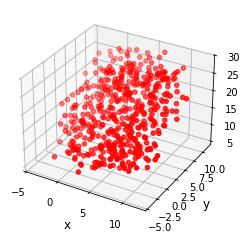

In [21]:
# Creating a pointcloud.
pc = o3d.io.read_point_cloud(path + "TestData/spread_points.ply")
# Convert Open3D point cloud to a numpy array of shape (N, 3)
xyz = np.asarray(pc.points)

fig = plt.figure(figsize=(6,4))
ax = plt.axes(projection='3d')
# Scatter plot the 3D points. 
# Columns 0, 1, 2 correspond to x, y, z coordinates respectively.
ax.scatter3D(xyz[:,0], xyz[:,1], xyz[:,2], color = 'red')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
plt.show()

In [22]:
## We want to predict Z based on X and Y.
# xy contains the first two columns (Inputs)
xy = xyz[:,:2] 
# z contains the last column (Target) reshaped to (N, 1)
z = xyz[:,2].reshape(-1,1) 

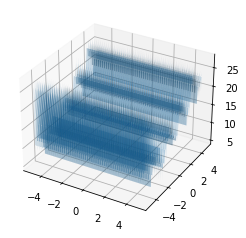

In [23]:
# Perform regression to fit a plane: z = beta_0 + beta_1*x + beta_2*y
# Note: This computes the predicted Z values for the *original* xy points.
predicted_zz = regression(xy, z)

start, end, n = -5, 5, z.shape[0]

fig = plt.figure(figsize=(6,4))
ax = plt.axes(projection='3d')

# Create a meshgrid for plotting the plane surface
x_t = np.linspace(start, end, n)
y_t = np.linspace(start, end, n)
xx, yy = np.meshgrid(x_t, y_t)

# Note: Ideally, to plot the full plane surface, we should predict Z values for the *grid points* (xx, yy), 
# not just reuse 'predicted_zz' which matches the scatter points.
# However, for visualization here, we use the predicted values.
ax.plot_surface(xx, yy, predicted_zz, alpha=0.2)